In [89]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation, PillowWriter
from IPython.display import HTML
from matplotlib.widgets import Slider
from scipy.signal import butter, filtfilt, resample
import os

In [90]:
print(os.getcwd()) 
print(os.listdir())   
!afconvert -f WAVE -d LEI16 Stine.wav Stine_fixed.wav

/Users/annesofiethybo/Library/Mobile Documents/com~apple~CloudDocs/NuMe Projekt/NumMeProject
['Stine_fixed.wav', '.DS_Store', 'Nume dag 2.ipynb', 'README.md', 'mathias.wav', '.git', 'test.ipynb', 'Stine.wav', 'Lydarbejde.ipynb']


$\text{Grid and the physical space}$

In [91]:
#Grid
c=343#m/
Lx=10#m #length of the classroom
Ly=6 #m

Nx=200
Ny=120

dx = Lx/(Nx - 1)
dy = Ly/(Ny - 1)

x=np.arange(Nx)*dx
y=np.arange(Ny)*dy
X,Y =np.meshgrid(x,y)




#time steps to match spatial resolution 
courant_limit=1.0/(c*np.sqrt(1/dx**2+1/dy**2)) 
dt=0.7*courant_limit  #to make sure it stays stable
Nt=6000 

courant=c*dt*np.sqrt(1/dx**2+1/dy**2) #should be <= 1 for stability.

print(f"dx={dx:.4f} m,dy= {dy:.4f} m,dt = {dt:.2e} s")
print(f"Courant number={courant:.3f} (should below <= 1)")
if courant>1:
    print("unstable")
 
f_max =c/(10*max(dx,dy)) #it takes about 10 grid points to resolve a wavelength, so the max frequency our simulation can resolve is affected by grid spacing.
print(f"max frequency resolved for this grid={f_max:.0f} Hz")

dx=0.0503 m,dy= 0.0504 m,dt = 7.26e-05 s
Courant number=0.700 (should below <= 1)
max frequency resolved for this grid=680 Hz


In [92]:
 
import numpy as np
import soundfile as sf
from scipy.signal import butter, filtfilt, resample
 
 
def load_signal(wav_path, dt, Nt, f_max, target_amplitude=0.5):
    """
    Load a wav file and reshape it into exactly what the simulation
    loop expects: one number per time step, band-limited to what the
    grid can actually carry, matching the sim's implied sample rate.
    """
    audio,sr = sf.read(wav_path)
    if audio.ndim > 1:
        audio = audio.mean(axis=1) 
 
    #1. Low-pass filter below our f_max
    nyquist = sr / 2
    cutoff = min(f_max / nyquist, 0.99)
    b,a = butter(4, cutoff, btype="low")
    audio_filtered = filtfilt(b, a, audio)
 
    #2. Resample so one audio sample=one simulation time step
    target_sr = 1 / dt
    n_target = int(len(audio_filtered) * target_sr / sr)
    audio_resampled = resample(audio_filtered, n_target)
 
    #3.Fit to the simulation length (pad with silence, or trim).
    if len(audio_resampled) < Nt:
        pad = np.zeros(Nt - len(audio_resampled))
        signal = np.concatenate([audio_resampled, pad])
    else:
        signal = audio_resampled[:Nt]
 
    # 4. Normalise so the amplitude is comparable to what you were using
    #with the sine-wave version (so your plot's colour scale still works).
    signal = target_amplitude * signal / np.max(np.abs(signal))
 
    return signal

signal = load_signal("Stine_fixed.wav", dt, Nt, f_max, target_amplitude=0.5)

In [93]:
#Boundaries/walls and their reflection coefficients.
R_board=0.90 #x=0
R_back=0.98 #x=Lx
R_window=0.8#y=0   
R_plainwall=0.98 #y=Ly 
 

In [94]:
#Mathias

#initial position
mathias_x=1
mathias_y=Ly/2

r=np.sqrt((X - mathias_x)**2+(Y - mathias_y)**2) #distance from mathias


mathias_col = int(round(mathias_x / dx)) #column index
mathias_row= int(round(mathias_y / dy))#row index

#sound. simple sine wave
f=150 #hz
omega=2*np.pi*f
amplitude=0.5
 
t=np.arange(Nt)*dt
sin_wave= amplitude*np.sin(omega *t)
sin_wave[:100]*=np.linspace(0,1,100) 

'''#sound 
f=150 #hz
omega=2*np.pi*f
k=omega/c #wavenumber

sigma=0.1 #standard dev of the gaussian

def gaussian(X,Y,mathias_x,mathias_y,sigma): 
    u = np.exp(-(r)/(2*sigma**2) )
    return u
    
u=gaussian(X,Y,mathias_x,mathias_y,sigma) 

#making the gaussian time dependent by multiplyihn it with a sin wave/carrier wave
gaussian_envelope=gaussian(X,Y,mathias_x,mathias_y,sigma) 
carrier=np.sin(k*r-omega*dt)
wave=gaussian_envelope*carrier'''

'#sound \nf=150 #hz\nomega=2*np.pi*f\nk=omega/c #wavenumber\n\nsigma=0.1 #standard dev of the gaussian\n\ndef gaussian(X,Y,mathias_x,mathias_y,sigma): \n    u = np.exp(-(r)/(2*sigma**2) )\n    return u\n\nu=gaussian(X,Y,mathias_x,mathias_y,sigma) \n\n#making the gaussian time dependent by multiplyihn it with a sin wave/carrier wave\ngaussian_envelope=gaussian(X,Y,mathias_x,mathias_y,sigma) \ncarrier=np.sin(k*r-omega*dt)\nwave=gaussian_envelope*carrier'

In [95]:
%matplotlib widget

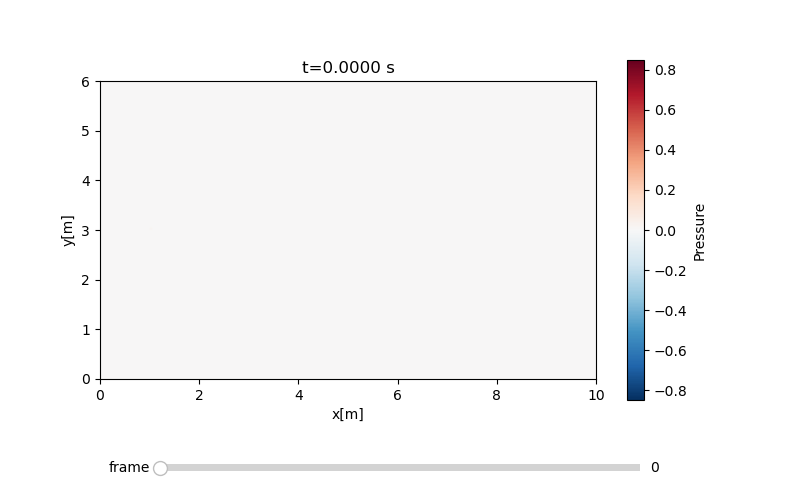

In [96]:
#fra diskretisering af bølgeligningen får vi u^n, u^n-1, u^n+1 med central diff scheme
u_old=np.zeros((Ny,Nx))
u=np.zeros((Ny,Nx))
u_new=np.zeros((Ny,Nx))

#updates for loop using our new travlling gaussian and also including the new boundary conditions that takes into account the reflection coefficients of the walls.

#for slider viewer
save_every=20 
frames=[]
times=[]

C2=(c*dt/dx)**2 #thecourant number squsred, used to ensure stability

for n in range(Nt):
 
    #interior 
    u_new[1:-1, 1:-1]=(
        2*u[1:-1, 1:-1]- u_old[1:-1,1:-1]
        + C2*(u[1:-1,2:]+ u[1:-1, :-2]
              +u[2:, 1:-1]+ u[:-2,1:-1]
              -4*u[1:-1, 1:-1]))
 
    #left wall(x=0)
    u_new[1:-1,0]= (
        2*u[1:-1,0] - u_old[1:-1,0]
        + C2*(u[1:-1,1]+ R_board*u[1:-1,1]#takes the value of the next grid point and multiplies it with the relfection coefficient 
              +u[2:,0]+ u[:-2,0]
              -4*u[1:-1,0]) )
 
    #right wall(x=Lx)
    u_new[1:-1, -1]=(
        2*u[1:-1, -1]- u_old[1:-1, -1]
        + C2*(u[1:-1,-2]+ R_back*u[1:-1, -2]
              + u[2:, -1]+ u[:-2, -1]
              - 4*u[1:-1, -1]))
 
    #window wall (y=0)
    u_new[0, 1:-1] = (
        2*u[0, 1:-1] - u_old[0, 1:-1]
        + C2*(u[0, 2:] + u[0, :-2]
              + u[1, 1:-1] + R_window*u[1, 1:-1]
              - 4*u[0, 1:-1]))
 
    #wall by door/plain wall (y=Ly)
    u_new[-1, 1:-1] = (
        2*u[-1, 1:-1] - u_old[-1, 1:-1]
        + C2*(u[-1, 2:] + u[-1, :-2]
              + u[-2, 1:-1] + R_plainwall*u[-2, 1:-1]
              - 4*u[-1, 1:-1]))

    #adding new sound wave from his position
    u_new[mathias_row, mathias_col]=u_new[mathias_row, mathias_col]+signal[n]
    
    #updating
    u_old=u.copy()
    u=u_new.copy()
 
    if n%save_every== 0:
        frames.append(u.copy())
        times.append(n*dt)
 
frames=np.array(frames)

 
#slider 
vmax = np.max(np.abs(frames))*0.5
 
fig, ax = plt.subplots(figsize=(8, 5))
plt.subplots_adjust(bottom=0.2)
im = ax.imshow(frames[0], origin='lower', extent=[0, Lx, 0, Ly],
               cmap='RdBu_r',vmin=-vmax, vmax=vmax)
ax.set_xlabel("x[m]")
ax.set_ylabel("y[m]")
title=ax.set_title(f"t={times[0]:.4f} s")
plt.colorbar(im,ax=ax,label="Pressure")
 
ax_slider=plt.axes([0.2, 0.05, 0.6, 0.03])
slider=Slider(ax_slider, "frame", 0, len(frames) - 1, valinit=0, valstep=1)
 
def update(val): 
    idx = int(slider.val)
    im.set_data(frames[idx])
    title.set_text(f"t = {times[idx]:.4f} s")
    fig.canvas.draw_idle()
 
slider.on_changed(update)
plt.show()